# Taller 04 - Descubriendo Patrones Musicales con Spotify

## Estudiante
Diana Zetabobo

## Objetivo

Aplicar técnicas de aprendizaje no supervisado para descubrir grupos de canciones utilizando PCA y algoritmos de Clustering.

In [2]:
# =====================================
# BLOQUE 1 - IMPORTACIÓN DE LIBRERÍAS
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
print("¡Las librerías cargaron correctamente!")

¡Las librerías cargaron correctamente!


In [4]:
# =====================================
# BLOQUE 2 - CARGA DEL DATASET
# =====================================

# Leemos el archivo CSV
df = pd.read_csv("spotifydataset.csv")

----head() muestra las primeras 5 filas.

In [5]:
df.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


---¿Cuántas filas y columnas tiene?

In [6]:
df.shape

(1000, 23)

---Nombres de las columnas

In [7]:
df.columns

Index(['Unnamed: 0', 'artist_name', 'genres', 'followers', 'artist_popularity',
       'artist_url', 'track_name', 'album_name', 'release_date', 'duration_ms',
       'explicit', 'track_popularity', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo'],
      dtype='str')

In [8]:
# =====================================
# BLOQUE 3 - SELECCIÓN DE VARIABLES
# =====================================

columnas_audio = [
    'track_popularity',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

df_audio = df[columnas_audio]

In [9]:
df_audio.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [10]:
df_audio.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


--Revisar Datos Faltantes

In [12]:
df_audio.isnull().sum()

track_popularity    0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64

--Tipo de Datos

In [13]:
df_audio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_popularity  1000 non-null   int64  
 1   danceability      1000 non-null   float64
 2   energy            1000 non-null   float64
 3   key               1000 non-null   int64  
 4   loudness          1000 non-null   float64
 5   mode              1000 non-null   int64  
 6   speechiness       1000 non-null   float64
 7   acousticness      1000 non-null   float64
 8   instrumentalness  1000 non-null   float64
 9   liveness          1000 non-null   float64
 10  valence           1000 non-null   float64
 11  tempo             1000 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 93.9 KB


In [15]:
# =====================================
# BLOQUE 3 - ESTANDARIZACIÓN
# =====================================

scaler = StandardScaler()

datos_escalados = scaler.fit_transform(df_audio)

In [19]:
scaler = StandardScaler()

datos_escalados = scaler.fit_transform(df_audio)

In [20]:
datos_escalados[:5]

array([[ 1.23867878,  0.20082268, -0.07019166, -0.06727728, -0.26212232,
         0.79455734, -0.53876157, -0.70766781, -0.33133643, -0.78971516,
        -0.95214957, -0.22473366],
       [ 1.0711256 ,  1.09815371, -0.14731349,  0.48644516,  0.29177032,
        -1.25856241, -0.53101782, -0.37693299, -0.33147133, -0.79521791,
        -0.29917199, -0.86111871],
       [ 0.98734901, -0.63070407, -1.43910416,  1.31702882, -0.51807433,
         0.79455734, -0.55093032,  1.39968444, -0.33147133, -0.08811359,
        -0.56551811, -1.33444882],
       [ 0.86168412,  0.23073372,  0.79260882, -1.45158338,  0.56179298,
         0.79455734, -0.65159909, -0.84619548, -0.33136306, -0.6548976 ,
         0.32803016, -0.14452574],
       [ 0.81979583,  1.05029605,  0.5516031 , -1.17472216,  0.12202903,
         0.79455734, -0.40490529, -0.26264765, -0.33118113, -0.52145573,
         1.16143576, -0.11217867]])

In [22]:
# =====================================
# BLOQUE 4 - PCA
# =====================================

pca = PCA(n_components=2)

componentes = pca.fit_transform(datos_escalados)

In [23]:
PCA(n_components=2)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [24]:
pca = PCA(n_components=2)

componentes = pca.fit_transform(datos_escalados)

In [25]:
pca = PCA(n_components=2)


In [26]:
componentes = pca.fit_transform(datos_escalados)

In [27]:
componentes[:5]

array([[ 0.06318536,  0.12911142],
       [ 0.60988526,  1.54281623],
       [-1.72577279,  1.12004716],
       [ 1.17871261, -0.07432293],
       [ 1.06028705,  0.94100667]])

In [28]:
pca.explained_variance_ratio_

array([0.24909434, 0.12774645])

Primer componente 24.91%
Segundo componente 12.77%
Entre ambos 24.91 + 12.77 = 37.68%

Los dos primeros componentes principales conservan aproximadamente el 37.7% de la variabilidad total del conjunto de datos, permitiendo representar visualmente las canciones en un espacio bidimensional para facilitar el análisis de agrupamientos.

In [29]:
# =====================================
# BLOQUE 5 - MÉTODO DEL CODO
# =====================================

inercias = []

for k in range(1,11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(componentes)
    inercias.append(modelo.inertia_)

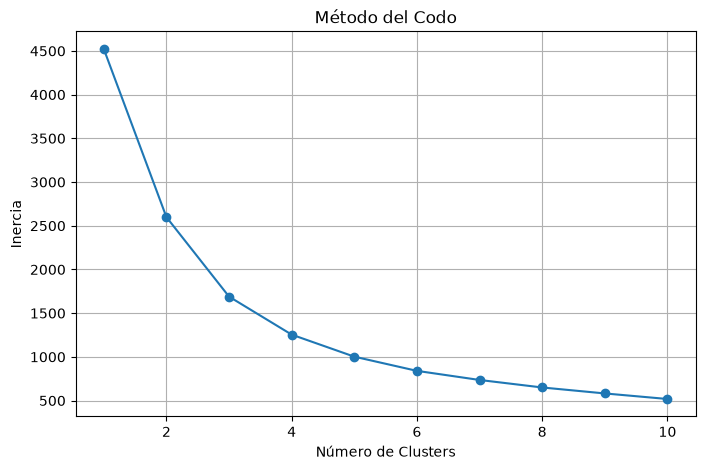

In [30]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inercias, marker='o')

plt.title("Método del Codo")

plt.xlabel("Número de Clusters")

plt.ylabel("Inercia")

plt.grid(True)

plt.show()

Para determinar el número óptimo de clusters se utilizó el Método del Codo. Al analizar la gráfica, se observó un cambio de pendiente alrededor de k=3, por lo que se seleccionaron 3 clusters. Esta elección permite un buen equilibrio entre simplicidad del modelo y capacidad para diferenciar grupos de canciones.

In [31]:
# =====================================
# BLOQUE 6 - K-MEANS
# =====================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(componentes)

In [32]:
df_audio["Cluster"] = clusters

In [33]:
df_audio.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842,0
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998,0
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726,1
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091,0
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998,0


In [34]:
df_audio["Cluster"].value_counts()

Cluster
0    524
2    337
1    139
Name: count, dtype: int64

## Distribución de los clusters

El algoritmo K-Means logró dividir las **1000 canciones** en **3 grupos**.

- Cluster 0: 524 canciones
- Cluster 1: 139 canciones
- Cluster 2: 337 canciones

Se observa que el Cluster 0 concentra la mayor cantidad de canciones, mientras que el Cluster 1 representa el grupo más pequeño. Esto indica que algunas características musicales son más comunes que otras dentro del conjunto de datos analizado.

In [36]:
df_pca = pd.DataFrame(componentes, columns=['PC1', 'PC2'])

df_pca['Cluster'] = clusters

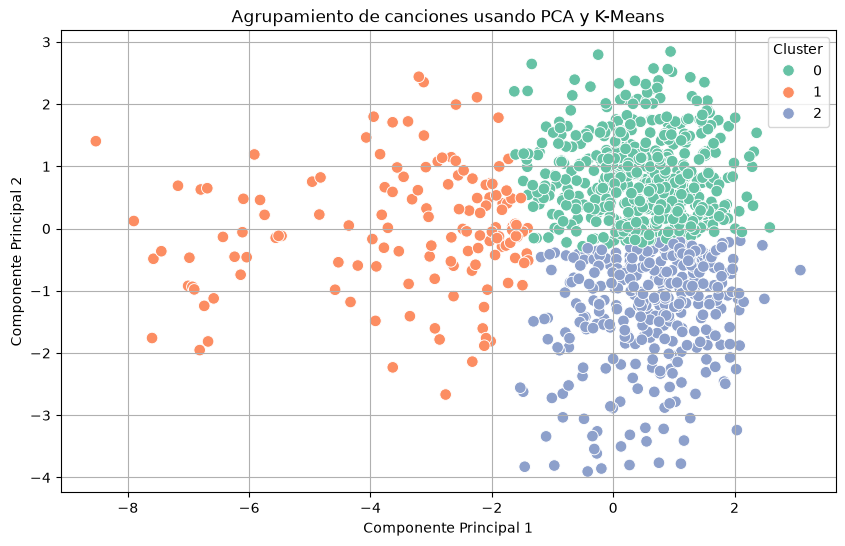

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title("Agrupamiento de canciones usando PCA y K-Means")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

## Interpretación del gráfico de dispersión

Cada punto representa una canción del conjunto de datos.

Los colores corresponden a los clusters encontrados por el algoritmo K-Means.

Se observa que el algoritmo logró identificar tres grupos de canciones con características de audio similares. Aunque existen algunas zonas donde los grupos se aproximan, la reducción de dimensionalidad mediante PCA permite visualizar claramente la distribución general de los clusters.

In [38]:
perfil_cluster = df_audio.groupby("Cluster").mean()

perfil_cluster

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,65.832061,0.708176,0.662971,5.543893,-6.458853,0.509542,0.103946,0.256341,0.003371,0.153290,0.618249,113.898718
1,45.158273,0.463007,0.316167,5.237410,-14.547496,0.697842,0.053814,0.723493,0.371276,0.132537,0.324691,117.381640
2,55.359050,0.522220,0.798866,4.777448,-5.204249,0.738872,0.087401,0.091845,0.063283,0.267251,0.437824,136.927217


<Figure size 1600x700 with 0 Axes>

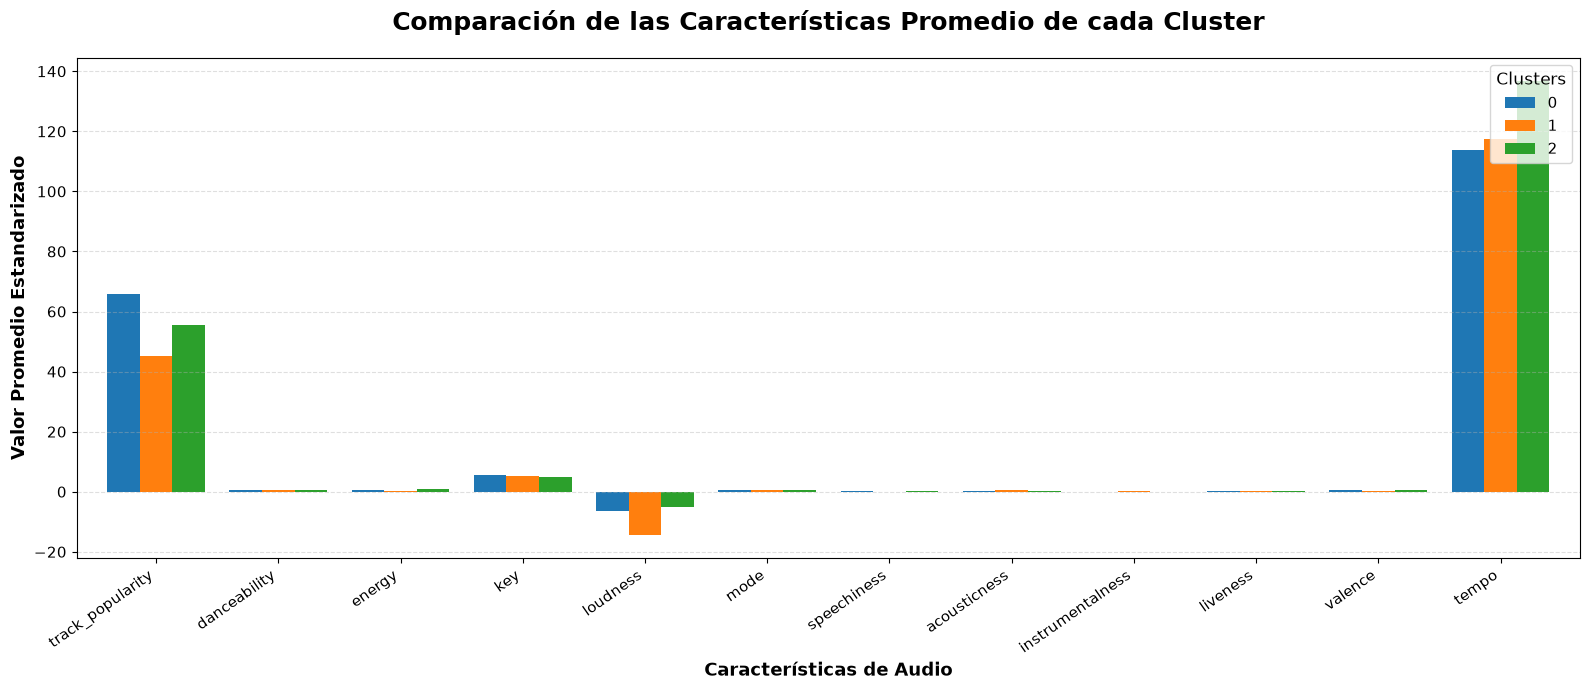

In [40]:
plt.figure(figsize=(16,7))

perfil_cluster.T.plot(
    kind='bar',
    figsize=(16,7),
    width=0.8
)

plt.title(
    "Comparación de las Características Promedio de cada Cluster",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    "Características de Audio",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Valor Promedio Estandarizado",
    fontsize=13,
    fontweight='bold'
)

plt.xticks(rotation=35, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    title="Clusters",
    fontsize=11,
    title_fontsize=12,
    loc='upper right'
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

## Interpretación de las características por cluster

El gráfico permite comparar el promedio de cada característica de audio entre los tres clusters.

Gracias a esta comparación es posible identificar qué atributos distinguen cada grupo de canciones, por ejemplo cuáles presentan mayor energía, cuáles son más bailables o cuáles poseen un carácter más acústico.

Esta información facilita comprender el perfil musical de cada cluster y permite interpretar los resultados desde una perspectiva de negocio.

In [42]:
perfil_cluster = df_audio.groupby("Cluster").mean()

perfil_cluster

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,65.832061,0.708176,0.662971,5.543893,-6.458853,0.509542,0.103946,0.256341,0.003371,0.153290,0.618249,113.898718
1,45.158273,0.463007,0.316167,5.237410,-14.547496,0.697842,0.053814,0.723493,0.371276,0.132537,0.324691,117.381640
2,55.359050,0.522220,0.798866,4.777448,-5.204249,0.738872,0.087401,0.091845,0.063283,0.267251,0.437824,136.927217


# Conclusiones

1. El algoritmo K-Means permitió identificar tres grupos de canciones con características musicales similares utilizando únicamente variables de audio, sin considerar el artista ni el género.

2. La popularidad, el tempo y la sonoridad fueron las variables que más diferenciaron los clusters. El Cluster 0 agrupa las canciones más populares, el Cluster 1 reúne canciones menos populares y con menor sonoridad, mientras que el Cluster 2 contiene canciones con un tempo más alto.

3. Estos resultados pueden utilizarse en plataformas de streaming para mejorar sistemas de recomendación, crear listas de reproducción basadas en características musicales y segmentar automáticamente nuevas canciones según su perfil de audio.